# Tracking History

The `tools` package contains utilities that interact with the learning process itself. For example, `tools.lineage` has utilities that enable tracking the lineage of individuals.

These utilities are as follows:

* `TrackParents` modifies the behaviour of an existing variator to record the parents in each offspring.

* `graph_lineage` takes a collection of individuals and plot their lineage. These individuals must be produced by variators enhanced with `TrackParents`.

In [1]:
import random
random.seed(1)
from evokit.core import Population
from evokit.evolvables.bitstring import BitString, CountBits
from evokit.tools.lineage import TrackParents
from evokit.tools.lineage import graph_lineage

To enable lineage tracking, take an existing algorithm (e.g. [OneMax](./onemax.ipynb)) and wrap the variator with `TrackParents`. Then, run the algorithm as normal.

In [2]:
T: int = 10

from evokit.evolvables.algorithms import SimpleLinearAlgorithm
from evokit.evolvables.bitstring import OnePointCrossover
from evokit.evolvables.selectors import TruncationSelector

another_pop = Population((BitString.random(size=20)
                                      for _ in range(50)))

ctrl = SimpleLinearAlgorithm(another_pop,
                             CountBits(),
                             TruncationSelector(budget=6),
                             TrackParents(OnePointCrossover(0.5), 9))

for _ in range (10):
    ctrl.step()

## Accessing Parents

`TrackParents` stores the parents of each offspring in its `.parents`. This can incur a memory cost: if an individual has at most $N$ parents and $K$ generations of parents are tracked, then at most

$$\sum^{K}_{i=1}{N^i}$$

extra individuals may be stored in memory. The cost can be significantly less in practice, as in the following example, because successful individuals often share common ancestors.

In [3]:
ctrl.population[0].parents

(<evokit.evolvables.bitstring.BitString at 0x2ea800c4b60>,
 <evokit.evolvables.bitstring.BitString at 0x2ea800c5220>)

## Visualising Parents

The `graph_lineage` function takes a number of individuals and outputs a `Digraph` (type from the `graphviz` module).

Connections can look messy with large populations. In this case, either reduce the node size with `use_tooltip=True` or increase vertical spacing with `vertical_spacing=N, N>1`.

Note that tooltips are only visible when the file is saved in SVG format. Do this with by setting `save_as=<file_name>`.

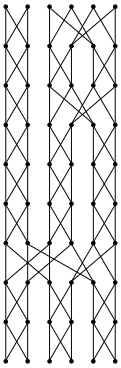

In [4]:
dot = graph_lineage(ctrl.population, use_tooltip=True)
dot